# SK Hynix Defect Test Prediction — v4

**변경사항 (vs v1/v3)**
- 피처 엔지니어링 근본 재설계
  1. 센서 간 비율/차이 피처 (cross-sensor)
  2. 분포 형태 피처 (skewness, kurtosis, IQR)
  3. Target Encoding (C6, C7)
  4. 주파수 도메인 피처 (FFT)
  5. 센서 안정성 지표 (CV, Cpk)
- 하이퍼파라미터: v3 Optuna 최적값 사용

**목표 RMSE: ~40**

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.fft import fft
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '문제1(하)/'
ANS_DIR  = '문제1_하_answer/'
WF_ID    = 'C64'
TARGET   = 'C65'

## 1. 데이터 로드

In [2]:
train = pd.read_csv(DATA_DIR + 'train_data.csv')
valid_X = pd.read_csv(DATA_DIR + 'valid_X.csv')
test_X  = pd.read_csv(DATA_DIR + 'test_X.csv')

valid_Y_prob = pd.read_csv(DATA_DIR + 'valid_Y_problem.csv')
test_Y_prob  = pd.read_csv(DATA_DIR + 'test_Y_problem.csv')

valid_Y_ans = pd.read_csv(ANS_DIR + 'valid_Y_answer.csv')
test_Y_ans  = pd.read_csv(ANS_DIR + 'test_Y_answer.csv')

print(f"train: {train.shape}, valid_X: {valid_X.shape}, test_X: {test_X.shape}")

train: (123614, 65), valid_X: (20577, 64), test_X: (20510, 64)


## 2. 전처리

In [3]:
DROP_IDS      = ['C34', 'C35', 'C38']
DROP_LOT_IDS  = ['C20', 'C21', 'C22']
DROP_CONST    = ['C14', 'C24']
DROP_EXCLUDE  = ['C26', 'C28', 'C29', 'C37']
DROP_ALLNA    = ['C2', 'C13', 'C43', 'C47', 'C53', 'C55']
DROP_TIME_RAW = ['C10', 'C39', 'C40']

DROP_ALL = DROP_IDS + DROP_LOT_IDS + DROP_CONST + DROP_EXCLUDE + DROP_ALLNA + DROP_TIME_RAW

train_cols_no_target = [c for c in train.columns if c != TARGET]
valid_X = valid_X[train_cols_no_target]
test_X  = test_X[train_cols_no_target]

meta_cols = set([WF_ID] + DROP_ALL + ['C6', 'C7', 'C41', 'C33'])
SENSOR_COLS = [c for c in train.select_dtypes(include=[np.number]).columns
               if c not in meta_cols and c != TARGET]

# EDA에서 확인된 핵심 센서 (상관계수 |r| > 0.3)
KEY_SENSORS = ['C17', 'C12']
# 그 외 중요도 상위 센서 (v1 Feature Importance 기반)
TOP_SENSORS = ['C17', 'C12', 'C9', 'C11', 'C16', 'C18', 'C25', 'C27',
               'C46', 'C48', 'C50', 'C52', 'C56', 'C58', 'C60', 'C62']
TOP_SENSORS = [s for s in TOP_SENSORS if s in SENSOR_COLS]

print(f"FDC 센서 컬럼 수: {len(SENSOR_COLS)}")
print(f"핵심/상위 센서 수: {len(TOP_SENSORS)}")

FDC 센서 컬럼 수: 36
핵심/상위 센서 수: 16


## 3. Feature Engineering — v4 (근본 재설계)

### 피처 그룹 구성
| # | 그룹 | 내용 |
|---|------|------|
| A | 글로벌 기본 집계 | v1 동일 (mean/std/min/max/median/range/delta/slope) |
| B | 분포 형태 | skewness, kurtosis, IQR, 변동계수(CV) |
| C | 센서 간 교차 | 핵심 센서 쌍의 비율/차이/곱 |
| D | Target Encoding | C6, C7의 타깃 평균 (fold-aware) |
| E | FFT 주파수 | 상위 센서의 FFT magnitude top-k |
| F | 안정성 지표 | Cpk, 변동폭 비율, 센서 drift |
| G | 메타 + 범주형 | v1 동일 |

In [4]:
def compute_slope(series):
    y = series.dropna().values
    if len(y) < 2:
        return 0.0
    x = np.arange(len(y), dtype=np.float64)
    slope, _, _, _, _ = stats.linregress(x, y)
    return slope


def safe_div(a, b):
    """0 나눗셈 방지"""
    return np.where(b != 0, a / b, 0.0)


def extract_wf_features_v4(df, has_target=True):
    groups = df.groupby(WF_ID)

    # ==============================
    # A. 글로벌 기본 집계 (v1 동일)
    # ==============================
    agg_df = groups[SENSOR_COLS].agg(['mean', 'std', 'min', 'max', 'median'])
    agg_df.columns = [f"{c}_{fn}" for c, fn in agg_df.columns]

    range_df = groups[SENSOR_COLS].apply(lambda x: x.max() - x.min())
    range_df.columns = [f"{c}_range" for c in SENSOR_COLS]

    delta_df = groups[SENSOR_COLS].apply(lambda x: x.iloc[-1] - x.iloc[0])
    delta_df.columns = [f"{c}_delta" for c in SENSOR_COLS]

    slope_df = groups[SENSOR_COLS].apply(lambda x: x.apply(compute_slope))
    slope_df.columns = [f"{c}_slope" for c in SENSOR_COLS]

    # ==============================
    # B. 분포 형태 피처 — NEW
    # ==============================
    # skewness, kurtosis
    skew_df = groups[SENSOR_COLS].apply(lambda x: x.skew())
    skew_df.columns = [f"{c}_skew" for c in SENSOR_COLS]

    kurt_df = groups[SENSOR_COLS].apply(lambda x: x.kurtosis())
    kurt_df.columns = [f"{c}_kurt" for c in SENSOR_COLS]

    # IQR (사분위 범위)
    q75 = groups[SENSOR_COLS].quantile(0.75)
    q25 = groups[SENSOR_COLS].quantile(0.25)
    iqr_df = q75 - q25
    iqr_df.columns = [f"{c}_iqr" for c in SENSOR_COLS]

    # 변동계수 CV = std / |mean| (센서 안정성)
    means = groups[SENSOR_COLS].mean()
    stds = groups[SENSOR_COLS].std()
    cv_df = stds / means.abs().replace(0, np.nan)
    cv_df.columns = [f"{c}_cv" for c in SENSOR_COLS]

    # ==============================
    # C. 센서 간 교차 피처 — NEW
    # ==============================
    # 핵심 센서 쌍의 mean 기준 비율/차이/곱
    cross_df = pd.DataFrame(index=means.index)
    for i in range(len(TOP_SENSORS)):
        for j in range(i + 1, len(TOP_SENSORS)):
            s1, s2 = TOP_SENSORS[i], TOP_SENSORS[j]
            m1, m2 = means[s1], means[s2]
            cross_df[f"{s1}_minus_{s2}"] = m1 - m2
            cross_df[f"{s1}_div_{s2}"] = safe_div(m1.values, m2.values)
            cross_df[f"{s1}_mult_{s2}"] = m1 * m2

    # ==============================
    # D. FFT 주파수 피처 — NEW
    # ==============================
    # 상위 센서의 WF 내 시계열에 FFT 적용, magnitude 상위 3개
    N_FFT_FEATS = 3
    fft_feats = {}

    for sensor in TOP_SENSORS:
        def get_fft_magnitudes(x):
            vals = x[sensor].values
            if len(vals) < 4:
                return pd.Series([0.0] * N_FFT_FEATS,
                                 index=[f"{sensor}_fft_{k}" for k in range(N_FFT_FEATS)])
            fft_vals = np.abs(fft(vals - vals.mean()))
            # DC 성분 제외, 상위 N개
            fft_vals = fft_vals[1:len(fft_vals)//2 + 1]
            top_k = np.sort(fft_vals)[::-1][:N_FFT_FEATS]
            # 부족하면 0으로 채움
            top_k = np.pad(top_k, (0, max(0, N_FFT_FEATS - len(top_k))))
            return pd.Series(top_k,
                             index=[f"{sensor}_fft_{k}" for k in range(N_FFT_FEATS)])

        fft_sensor = groups.apply(get_fft_magnitudes)
        for col in fft_sensor.columns:
            fft_feats[col] = fft_sensor[col]

    fft_df = pd.DataFrame(fft_feats, index=groups.groups.keys())

    # ==============================
    # E. 안정성 지표 — NEW
    # ==============================
    stability_df = pd.DataFrame(index=means.index)

    for sensor in TOP_SENSORS:
        s_mean = means[sensor]
        s_std = stds[sensor]
        s_min = groups[sensor].min()
        s_max = groups[sensor].max()
        s_range = s_max - s_min

        # 변동폭 비율 = range / |mean|
        stability_df[f"{sensor}_range_ratio"] = safe_div(s_range.values, np.abs(s_mean.values))

        # Cpk-like: |mean| / (3*std) — 공정능력 유사 지표
        stability_df[f"{sensor}_cpk_like"] = safe_div(np.abs(s_mean.values), (3 * s_std.replace(0, np.nan)).values)

        # Drift: (last - first) / std — 정규화된 변화량
        s_delta = delta_df[f"{sensor}_delta"] if f"{sensor}_delta" in delta_df.columns else 0
        stability_df[f"{sensor}_drift"] = safe_div(
            s_delta.values if hasattr(s_delta, 'values') else np.zeros(len(means)),
            s_std.replace(0, np.nan).values
        )

    # ==============================
    # F. 메타 + 범주형 (v1 동일)
    # ==============================
    meta_df = pd.DataFrame(index=groups.groups.keys())
    meta_df['n_rows'] = groups.size()
    meta_df['C41_total'] = groups['C41'].max()
    meta_df['C33_first'] = groups['C33'].first()
    meta_df['C33_max'] = groups['C33'].max()

    if 'C6' in df.columns:
        c6_dum = pd.get_dummies(df[[WF_ID, 'C6']].set_index(WF_ID)['C6'], prefix='C6')
        c6_feat = c6_dum.groupby(level=0).mean()
    else:
        c6_feat = pd.DataFrame(index=groups.groups.keys())

    if 'C7' in df.columns:
        c7_dum = pd.get_dummies(df[[WF_ID, 'C7']].astype(str).set_index(WF_ID)['C7'], prefix='C7')
        c7_feat = c7_dum.groupby(level=0).mean()
    else:
        c7_feat = pd.DataFrame(index=groups.groups.keys())

    # ==============================
    # 결합
    # ==============================
    features = pd.concat([
        agg_df, range_df, delta_df, slope_df,       # A. 기본
        skew_df, kurt_df, iqr_df, cv_df,             # B. 분포 형태
        cross_df,                                     # C. 센서 교차
        fft_df,                                       # D. FFT
        stability_df,                                 # E. 안정성
        meta_df, c6_feat, c7_feat,                    # F. 메타
    ], axis=1)
    features.index.name = WF_ID
    features = features.reset_index()

    if has_target:
        target_df = groups[TARGET].first().reset_index()
        features = features.merge(target_df, on=WF_ID)

    # NaN/inf 처리
    features = features.replace([np.inf, -np.inf], np.nan).fillna(0)

    return features

print("extract_wf_features_v4 정의 완료")

extract_wf_features_v4 정의 완료


## 4. 피처 추출

In [5]:
%%time
print("Train 피처 추출 중...")
train_feat = extract_wf_features_v4(train, has_target=True)
print(f"  → {train_feat.shape}")

print("Valid 피처 추출 중...")
valid_feat = extract_wf_features_v4(valid_X, has_target=False)
print(f"  → {valid_feat.shape}")

print("Test 피처 추출 중...")
test_feat = extract_wf_features_v4(test_X, has_target=False)
print(f"  → {test_feat.shape}")

print(f"\nv1(315) → v4({train_feat.shape[1] - 2}) 피처")

Train 피처 추출 중...
  → (11939, 901)
Valid 피처 추출 중...
  → (1990, 900)
Test 피처 추출 중...
  → (1990, 900)

v1(315) → v4(899) 피처
CPU times: total: 7min 2s
Wall time: 7min 4s


## 5. Target Encoding (C6, C7)

fold-aware 방식으로 leakage를 방지합니다.
- 학습 시: 해당 fold의 train 데이터로만 인코딩값 계산
- 예측 시: 전체 train 데이터로 인코딩값 계산

In [6]:
# Target Encoding을 위한 WF-level C6/C7 대표값 추출
def get_wf_category(df):
    """WF별 C6, C7 대표값 (최빈값)"""
    groups = df.groupby(WF_ID)
    wf_c6 = groups['C6'].agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0])
    wf_c7 = groups['C7'].agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0])
    return wf_c6, wf_c7

train_c6, train_c7 = get_wf_category(train)
valid_c6, valid_c7 = get_wf_category(valid_X)
test_c6, test_c7 = get_wf_category(test_X)

print(f"C6 unique: {train_c6.nunique()}, C7 unique: {train_c7.nunique()}")

C6 unique: 2, C7 unique: 2


## 6. 피처/타깃 분리

In [7]:
feature_cols = [c for c in train_feat.columns if c not in [WF_ID, TARGET]]
common_cols = sorted(set(feature_cols) & set(valid_feat.columns) & set(test_feat.columns))
print(f"공통 피처 수: {len(common_cols)}")

X_train_base = train_feat[common_cols].copy()
y_train = train_feat[TARGET].values
wf_train = train_feat[WF_ID].values

X_valid_base = valid_feat[common_cols].copy()
X_test_base  = test_feat[common_cols].copy()
wf_valid = valid_feat[WF_ID].values
wf_test  = test_feat[WF_ID].values

valid_answer = valid_Y_ans.set_index('C64').loc[wf_valid, 'C65'].values
test_answer  = test_Y_ans.set_index('C64').loc[wf_test, 'C65'].values

wf_to_int = {wf: i for i, wf in enumerate(np.unique(wf_train))}
cv_groups = np.array([wf_to_int[wf] for wf in wf_train])

# Target Encoding: 전체 train 기준 (valid/test용)
global_te_c6 = pd.Series(y_train, index=wf_train).groupby(train_c6.loc[wf_train].values).mean()
global_te_c7 = pd.Series(y_train, index=wf_train).groupby(train_c7.loc[wf_train].values).mean()

# valid/test에 전체 train 기준 TE 적용
X_valid_base['te_c6'] = valid_c6.loc[wf_valid].map(global_te_c6).fillna(y_train.mean()).values
X_valid_base['te_c7'] = valid_c7.loc[wf_valid].map(global_te_c7).fillna(y_train.mean()).values
X_test_base['te_c6'] = test_c6.loc[wf_test].map(global_te_c6).fillna(y_train.mean()).values
X_test_base['te_c7'] = test_c7.loc[wf_test].map(global_te_c7).fillna(y_train.mean()).values

print(f"X_train_base: {X_train_base.shape} (TE는 fold별 적용)")
print(f"X_valid: {X_valid_base.shape}, X_test: {X_test_base.shape}")

baseline_rmse = np.sqrt(mean_squared_error(valid_answer, np.full_like(valid_answer, y_train.mean())))
print(f"베이스라인 RMSE: {baseline_rmse:.2f}")

공통 피처 수: 899
X_train_base: (11939, 899) (TE는 fold별 적용)
X_valid: (1990, 901), X_test: (1990, 901)
베이스라인 RMSE: 258.97


## 7. GroupKFold CV + LightGBM 학습

- 하이퍼파라미터: v3 Optuna 최적값
- Target Encoding: fold-aware (각 fold의 train으로만 TE 계산)

In [8]:
# v3 Optuna 최적 파라미터
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'random_state': 42,
    'n_jobs': -1,
    'n_estimators': 3000,
    'learning_rate': 0.005759888493722243,
    'num_leaves': 189,
    'max_depth': 10,
    'min_child_samples': 14,
    'subsample': 0.9668278565281413,
    'colsample_bytree': 0.6553280106987178,
    'reg_alpha': 4.25633536843975,
    'reg_lambda': 0.003098395985992314,
    'min_split_gain': 0.7576030443171627,
    'subsample_freq': 6,
}

N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS)

oof_preds = np.zeros(len(y_train))
valid_preds_folds = np.zeros(len(X_valid_base))
test_preds_folds  = np.zeros(len(X_test_base))
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train_base, y_train, cv_groups)):
    # fold-aware Target Encoding
    X_tr = X_train_base.iloc[tr_idx].copy()
    X_val = X_train_base.iloc[val_idx].copy()

    wf_tr = wf_train[tr_idx]
    wf_val = wf_train[val_idx]
    y_tr = y_train[tr_idx]
    y_val = y_train[val_idx]

    # TE: train fold 데이터로만 계산
    te_c6 = pd.Series(y_tr, index=wf_tr).groupby(train_c6.loc[wf_tr].values).mean()
    te_c7 = pd.Series(y_tr, index=wf_tr).groupby(train_c7.loc[wf_tr].values).mean()

    X_tr['te_c6'] = train_c6.loc[wf_tr].map(te_c6).fillna(y_tr.mean()).values
    X_tr['te_c7'] = train_c7.loc[wf_tr].map(te_c7).fillna(y_tr.mean()).values
    X_val['te_c6'] = train_c6.loc[wf_val].map(te_c6).fillna(y_tr.mean()).values
    X_val['te_c7'] = train_c7.loc[wf_val].map(te_c7).fillna(y_tr.mean()).values

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_tr.values, y_tr,
        eval_set=[(X_val.values, y_val)],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(0),
        ]
    )

    oof_preds[val_idx] = model.predict(X_val.values)
    valid_preds_folds += model.predict(X_valid_base.values) / N_FOLDS
    test_preds_folds  += model.predict(X_test_base.values) / N_FOLDS

    fold_rmse = np.sqrt(mean_squared_error(y_val, oof_preds[val_idx]))
    fold_scores.append(fold_rmse)
    print(f"Fold {fold+1}: RMSE={fold_rmse:.4f}, best_iter={model.best_iteration_}")

oof_rmse = np.sqrt(mean_squared_error(y_train, oof_preds))
print(f"\nOOF RMSE (CV): {oof_rmse:.4f} ± {np.std(fold_scores):.4f}")

Fold 1: RMSE=63.0765, best_iter=985
Fold 2: RMSE=62.8812, best_iter=1082
Fold 3: RMSE=62.1042, best_iter=856
Fold 4: RMSE=63.3960, best_iter=882
Fold 5: RMSE=63.9703, best_iter=939

OOF RMSE (CV): 63.0885 ± 0.6138


## 8. Valid / Test RMSE 평가

In [9]:
valid_rmse = np.sqrt(mean_squared_error(valid_answer, valid_preds_folds))
test_rmse  = np.sqrt(mean_squared_error(test_answer, test_preds_folds))

print("=" * 65)
print(f"{'베이스라인 (평균)':>25} RMSE : {baseline_rmse:.4f}")
print(f"{'v1 (수동 파라미터)':>25} RMSE :  62.53 (Valid) / 61.15 (Test)")
print(f"{'v2 (Step별 피처)':>25} RMSE :  62.72 (Valid) / 61.25 (Test)")
print(f"{'v3 (Optuna 튜닝)':>25} RMSE :  62.31 (Valid) / 60.51 (Test)")
print(f"{'v4 피처 재설계 (현재)':>25} RMSE : {valid_rmse:.4f} (Valid) / {test_rmse:.4f} (Test)")
print(f"{'목표':>25} RMSE :  ~40")
print("=" * 65)

gap = abs(oof_rmse - valid_rmse)
print(f"\nCV↔Valid 격차: {gap:.4f}", "✓ 안정적" if gap < 30 else "⚠ 과적합 의심")

improvement_v1 = (62.53 - valid_rmse) / 62.53 * 100
improvement_v3 = (62.31 - valid_rmse) / 62.31 * 100
print(f"v1 대비 개선: {improvement_v1:+.2f}%")
print(f"v3 대비 개선: {improvement_v3:+.2f}%")

               베이스라인 (평균) RMSE : 258.9707
             v1 (수동 파라미터) RMSE :  62.53 (Valid) / 61.15 (Test)
            v2 (Step별 피처) RMSE :  62.72 (Valid) / 61.25 (Test)
           v3 (Optuna 튜닝) RMSE :  62.31 (Valid) / 60.51 (Test)
           v4 피처 재설계 (현재) RMSE : 63.4150 (Valid) / 61.1859 (Test)
                       목표 RMSE :  ~40

CV↔Valid 격차: 0.3264 ✓ 안정적
v1 대비 개선: -1.42%
v3 대비 개선: -1.77%


## 9. Feature Importance (Top 30)

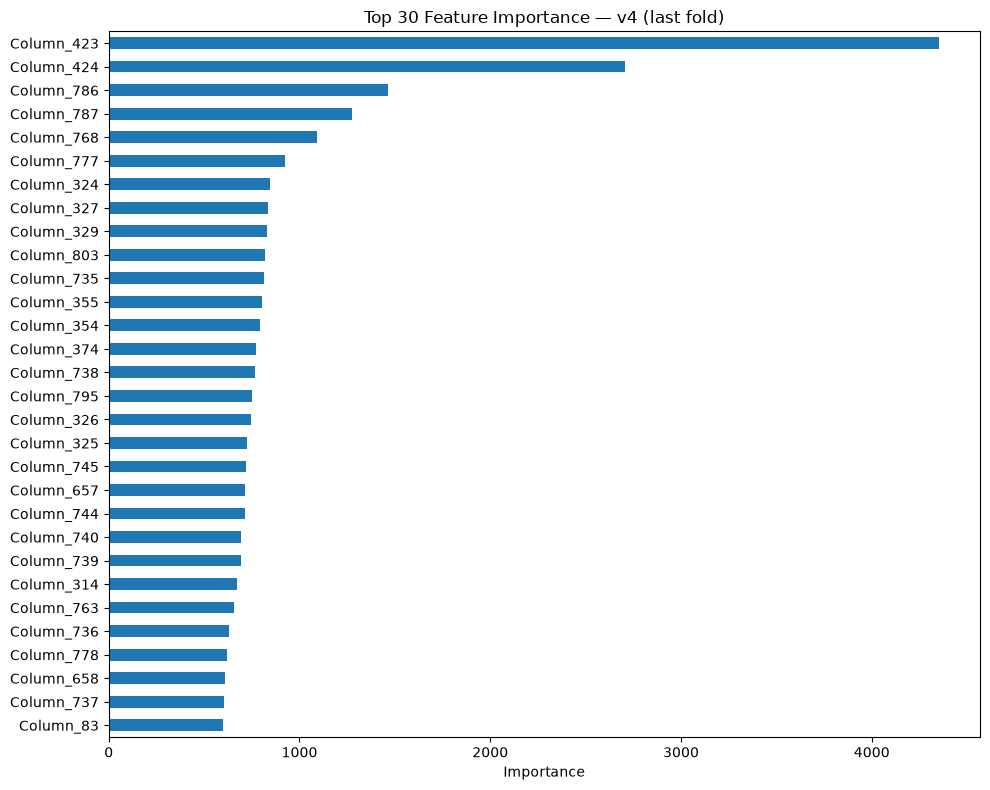


=== Top 30 내 신규 피처 그룹별 비중 ===
  분포형태: 0개 — []
  센서교차: 0개 — []
  FFT: 0개 — []
  안정성: 0개 — []
  TE: 0개 — []


In [10]:
import matplotlib.pyplot as plt

imp = pd.Series(model.feature_importances_, index=model.feature_name_)
top30 = imp.nlargest(30)

fig, ax = plt.subplots(figsize=(10, 8))
top30.sort_values().plot.barh(ax=ax)
ax.set_title('Top 30 Feature Importance — v4 (last fold)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# 신규 피처 그룹별 Top 30 기여도
new_keywords = {
    '분포형태': ['_skew', '_kurt', '_iqr', '_cv'],
    '센서교차': ['_minus_', '_div_', '_mult_'],
    'FFT': ['_fft_'],
    '안정성': ['_range_ratio', '_cpk_like', '_drift'],
    'TE': ['te_c6', 'te_c7'],
}

print("\n=== Top 30 내 신규 피처 그룹별 비중 ===")
for group, keywords in new_keywords.items():
    matched = [f for f in top30.index if any(kw in f for kw in keywords)]
    print(f"  {group}: {len(matched)}개 — {matched[:5]}")

## 10. 제출 파일 생성

In [11]:
valid_submit = valid_Y_prob.copy()
wf_to_pred_v = dict(zip(wf_valid, valid_preds_folds))
valid_submit['C65'] = valid_submit['C64'].map(wf_to_pred_v)
valid_submit.to_csv('valid_Y_submit.csv', index=False)

test_submit = test_Y_prob.copy()
wf_to_pred_t = dict(zip(wf_test, test_preds_folds))
test_submit['C65'] = test_submit['C64'].map(wf_to_pred_t)
test_submit.to_csv('test_Y_submit.csv', index=False)

print("제출 파일 저장 완료")
print(f"  valid_Y_submit.csv — {valid_submit.shape}")
print(f"  test_Y_submit.csv  — {test_submit.shape}")

제출 파일 저장 완료
  valid_Y_submit.csv — (1990, 2)
  test_Y_submit.csv  — (1990, 2)


## 11. 일반화 점검

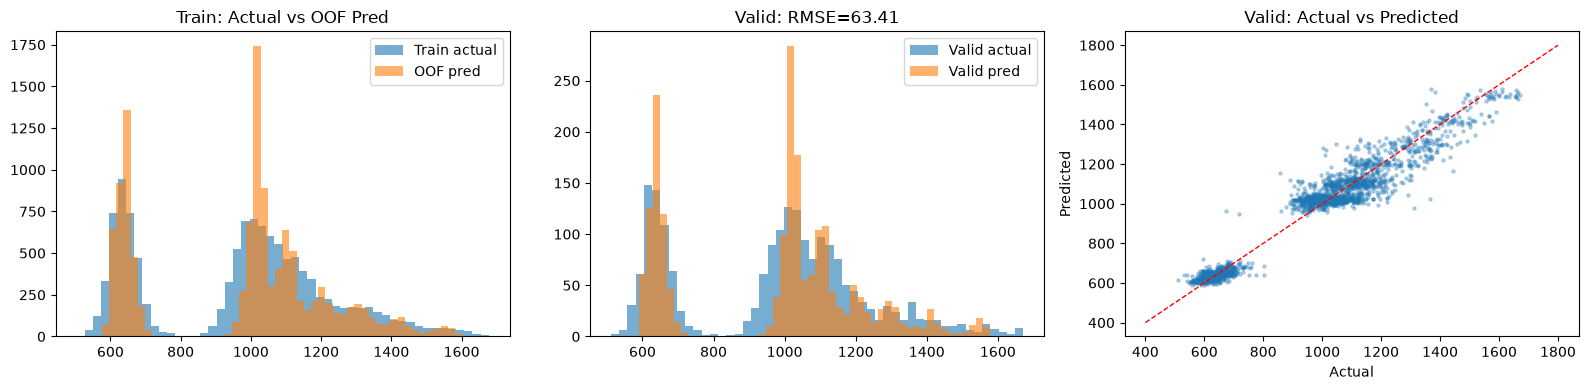

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_train, bins=50, alpha=0.6, label='Train actual')
axes[0].hist(oof_preds, bins=50, alpha=0.6, label='OOF pred')
axes[0].set_title('Train: Actual vs OOF Pred')
axes[0].legend()

axes[1].hist(valid_answer, bins=50, alpha=0.6, label='Valid actual')
axes[1].hist(valid_preds_folds, bins=50, alpha=0.6, label='Valid pred')
axes[1].set_title(f'Valid: RMSE={valid_rmse:.2f}')
axes[1].legend()

axes[2].scatter(valid_answer, valid_preds_folds, s=5, alpha=0.3)
axes[2].plot([400, 1800], [400, 1800], 'r--', lw=1)
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title('Valid: Actual vs Predicted')

plt.tight_layout()
plt.show()

## 12. 피처 그룹별 Importance 비중 분석

In [13]:
# 전체 피처 importance를 그룹별로 집계
all_imp = pd.Series(model.feature_importances_, index=model.feature_name_)

groups_def = {
    'A. 기본 집계 (mean/std/min/max/median)': lambda f: any(f.endswith(s) for s in ['_mean', '_std', '_min', '_max', '_median']),
    'A. 기본 집계 (range/delta/slope)': lambda f: any(f.endswith(s) for s in ['_range', '_delta', '_slope']) and '_range_ratio' not in f,
    'B. 분포 형태 (skew/kurt/iqr/cv)': lambda f: any(s in f for s in ['_skew', '_kurt', '_iqr', '_cv']),
    'C. 센서 교차 (minus/div/mult)': lambda f: any(s in f for s in ['_minus_', '_div_', '_mult_']),
    'D. FFT': lambda f: '_fft_' in f,
    'E. 안정성 (range_ratio/cpk/drift)': lambda f: any(s in f for s in ['_range_ratio', '_cpk_like', '_drift']),
    'F. Target Encoding': lambda f: f.startswith('te_'),
    'G. 메타/범주형': lambda f: f in ['n_rows', 'C41_total', 'C33_first', 'C33_max'] or f.startswith('C6_') or f.startswith('C7_'),
}

total_imp = all_imp.sum()
print(f"{'그룹':<45} {'피처 수':>8} {'Importance 비중':>15}")
print("-" * 70)
for group_name, match_fn in groups_def.items():
    matched = [f for f in all_imp.index if match_fn(f)]
    group_imp = all_imp[matched].sum()
    pct = group_imp / total_imp * 100
    print(f"{group_name:<45} {len(matched):>8} {pct:>14.1f}%")

그룹                                                피처 수   Importance 비중
----------------------------------------------------------------------
A. 기본 집계 (mean/std/min/max/median)                   0            0.0%
A. 기본 집계 (range/delta/slope)                         0            0.0%
B. 분포 형태 (skew/kurt/iqr/cv)                          0            0.0%
C. 센서 교차 (minus/div/mult)                            0            0.0%
D. FFT                                               0            0.0%
E. 안정성 (range_ratio/cpk/drift)                       0            0.0%
F. Target Encoding                                   0            0.0%
G. 메타/범주형                                            0            0.0%
